In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE

ROOT   = Path.cwd().parent
MODELS = ROOT / 'models'

df = pd.read_csv(ROOT / 'data' / 'raw' / 'Churn_Modelling.csv')
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled  = scaler.transform(X_test)

lr = joblib.load(MODELS / 'logistic_regression.pkl')
rf = joblib.load(MODELS / 'random_forest.pkl')


y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Models loaded successfully")
print(f"Test set: {X_test_scaled.shape[0]:,} rows")
print(f"LR  ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"RF  ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("Ready for evaluation cells")

Models loaded successfully
Test set: 2,000 rows
LR  ROC-AUC: 0.7463
RF  ROC-AUC: 0.8522
Ready for evaluation cells


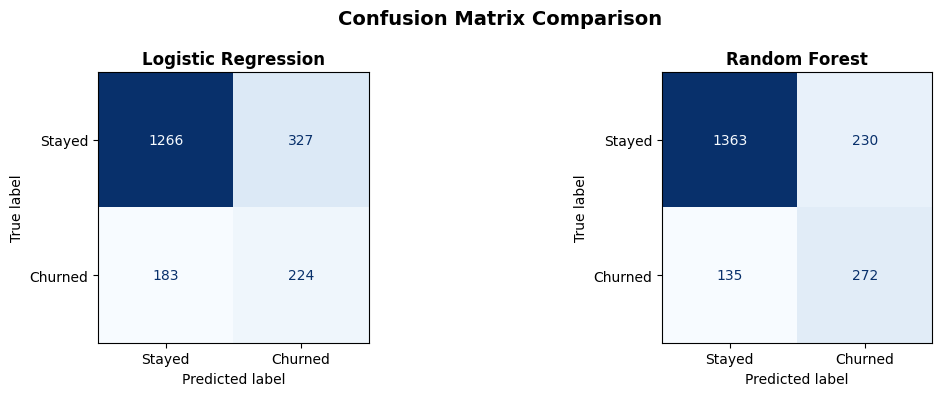

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed','Churned'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


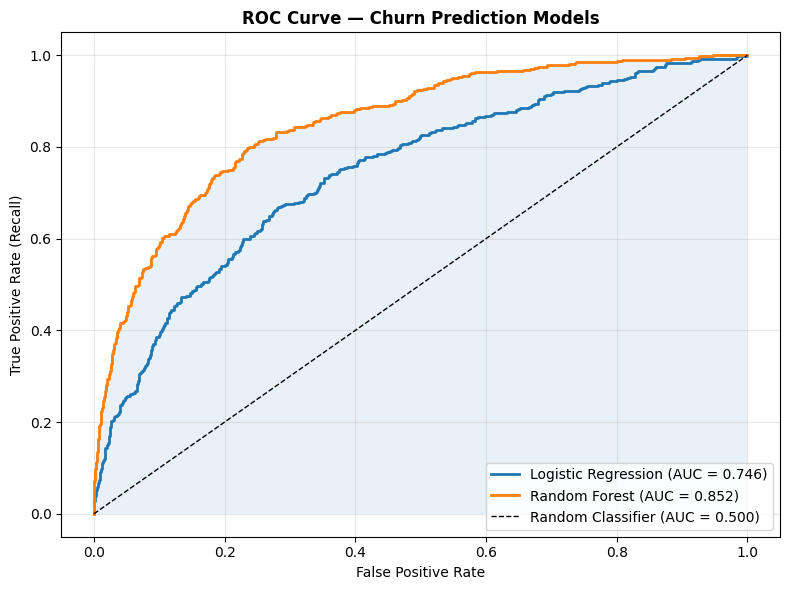

In [4]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr),
                      ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Prediction Models', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


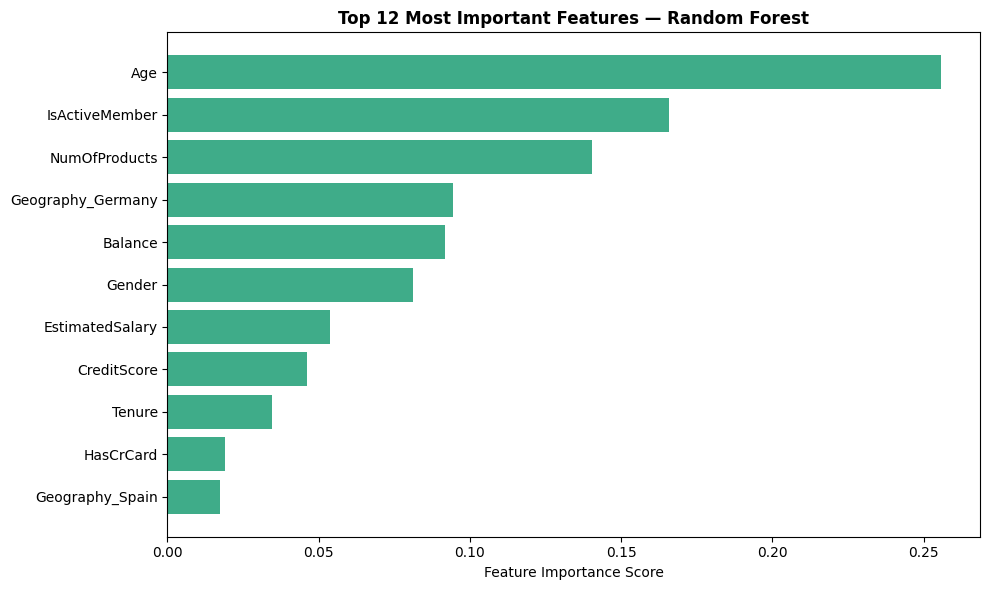

Top 10 churn predictors:
          feature  importance
              Age    0.255811
   IsActiveMember    0.165771
    NumOfProducts    0.140497
Geography_Germany    0.094434
          Balance    0.091612
           Gender    0.081303
  EstimatedSalary    0.053625
      CreditScore    0.046169
           Tenure    0.034678
        HasCrCard    0.018860


In [5]:
feature_names = X.columns.tolist()
importances   = rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 12 features
top12 = feat_imp.head(12)

plt.figure(figsize=(10, 6))
bars = plt.barh(top12['feature'][::-1], top12['importance'][::-1],
                color='#1D9E75', alpha=0.85)
plt.xlabel('Feature Importance Score')
plt.title('Top 12 Most Important Features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 churn predictors:')
print(feat_imp.head(10).to_string(index=False))
feat_imp.to_csv('../data/processed/feature_importance.csv', index=False)


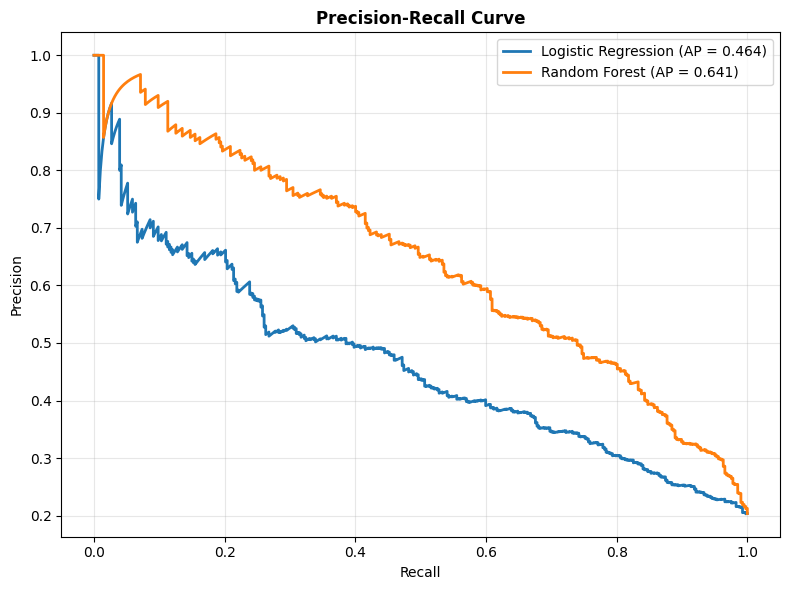

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr),
                      ('Random Forest', y_prob_rf)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, linewidth=2,
             label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
